# Ornstein-Uhlenbeck Simulation

This notebook present readers with a brief overview of the Ornstein-Uhlenbeck Process, which is used in everyday modern finance. We will delve into its mathematical formulation, implement and simulate it using Python and discuss a few real world applications in quantitative finance and systematic trading. For more information on the resources and content used in this notebook, please reference the following link: https://www.quantstart.com/articles/ornstein-uhlenbeck-simulation-with-python/

---
#### Motivation 

We all know that asset prices can be modelled using the Brownian motion. The **Ornstein-Uhlenbeck (OU) Process**, on the other hand, can be considered as a more advanced continuous-timed stochastic process used in modelling time series exhibiting mean reverting behaviour. This is particularly useful for interest rate modelling in derivatives pricing as well as for systematic trading when carrying out **algorithmic pairs trading**.

The key idea here is **Mean Reverting**...

Unlike a standard random walk or Brownian motion, which can drift indefinitely, the OU process tends to revert to a long-term mean over time. Mathematically, the OU process is a solution to a specific stochastic differential equation (SDE) that governs this mean-reverting behavior. The SDE for the OU process is given by:

$$
dX_{t} = \theta \left( \mu - X_t \right) dt + \sigma \, dW_t
$$

Where:
- $X_{t}$ represents the stochastic process at time $t$
- $\mu$ is the long term mean
- $\theta$ is the rate of mean reversion
- $\sigma$ is the volatility
- $dW_t$ is a Wiener process or standard Brownian motion

The OU process can be found in Financial areas used for modeling mean-reverting phenomenas, such as include interest rates, exchange rates, and volatility in financial markets. The Vasicek model, a popular model for interest rates, is directly derived from the OU process.

---
#### Application in Quantitative Finance

The Ornstein-Uhlenbeck process is fundamental in quantitative finance for several reasons. Its mean-reverting nature makes it a natural choice for modeling financial variables that do not exhibit random walk behavior but instead fluctuate around a stable long-term mean. This characteristic is crucial for modeling interest rates, where mean reversion reflects the central bank's influence to stabilize rates over time.

Furthermore, the OU process is used in asset pricing models, including the valuation of derivatives, and in risk management strategies. It also serves as a building block for more complex models, such as the Cox-Ingersoll-Ross (CIR) model, which extends the OU process to model interest rates with non-negative values.


**Pairs Trading Strategies**
> Pairs trading is a market-neutral strategy that involves taking offsetting positions in two correlated assets. The OU process is particularly useful in this context as it can model the spread between two assets, which is often mean-reverting. By modeling the spread with an OU process, traders can identify profitable entry and exit points when the spread deviates from its mean, anticipating a reversion to the mean and thus generating trading signals.
> For example, if the spread between two stocks widens beyond a certain threshold, a trader might short the outperforming stock and go long on the underperforming one, expecting the spread to revert to its historical average, thereby realizing a profit when the reversion occurs.


#### Solution to the Ornstein–Uhlenbeck SDE

As mentioned above, the Ornstein–Uhlenbeck (OU) process is defined by the stochastic differential equation:

$$
dX_t = \theta(\mu - X_t)\,dt + \sigma\,dW_t
$$

To solve this SDE, we apply the **integrating factor method**.

---

##### Step 1: Rewrite the SDE
> Rearrange the equation:
$
dX_t + \theta X_t\,dt = \theta \mu\,dt + \sigma\,dW_t
$

##### Step 2: Apply the Integrating Factor
> The integrating factor is:
$
e^{\theta t}
$

> Multiplying both sides by the integrating factor:
$
e^{\theta t} dX_t + \theta e^{\theta t} X_t\,dt
= \theta \mu e^{\theta t}\,dt + \sigma e^{\theta t}\,dW_t
$

##### Step 3: Express as a Product Differential
> Notice that the left-hand side is the differential of a product:
$
d\left( e^{\theta t} X_t \right)
= \theta \mu e^{\theta t}\,dt + \sigma e^{\theta t}\,dW_t
$

##### Step 4: Integrate
> Integrating both sides from \(0\) to \(t\):
$
e^{\theta t} X_t - X_0 = \theta \mu \int_0^t e^{\theta s} ds + \sigma \int_0^t e^{\theta s} dW_s
$

> Evaluating the deterministic integral:
$
\int_0^t e^{\theta s} ds = \frac{1}{\theta}\left(e^{\theta t} - 1\right)
$

##### Step 5: Final Explicit Solution
> Solving for \(X_t\):
$
X_t = X_0 e^{-\theta t} + \mu \left(1 - e^{-\theta t}\right) + \sigma \int_0^t e^{-\theta (t - s)} dW_s
$

> This is the **general solution** to the Ornstein–Uhlenbeck SDE.

### Simulating the Ornstein-Uhlenbeck Process

#### 1. Discretisation of the SDE

To simulate this process on a computer, we need to discretize the continuous-time SDE. A commonly used method is the **Euler-Maruyama discretisation**, which approximates the continuous process by considering small, discrete time steps. 

Let $\Delta t$ denote a small time step and let $ \varepsilon_t \sim \mathcal{N}(0,1)$. The discretized form of the Ornstein-Uhlenbeck process is given by:

$$
X_{t+\Delta t} = X_t + \theta(\mu - X_t)\Delta t + \sigma \sqrt{\Delta t}\,\varepsilon_t
$$

 
Here, $\varepsilon_t$ is a random variable drawn from a standard normal distribution (i.e., $ \varepsilon_t \sim \mathcal{N}(0,1)$). This discretization allows us to iteratively compute the value of $X_t$ over time, simulating the behavior of the OU process.

**Import the necessary libraries**

In [33]:
import numpy as np
import matplotlib.pyplot as plt

Next, we will specify all the parameters to the OU model

In [34]:
theta = 0.7 # Speed of reversion
mu = 0.0 # Long-term mean
sigma = 0.3 # Volatility
X0 = 1.0 # Initial value
T = 100.0 # Total time
dt = 0.01 # Time step
N = int(T / dt) # Number of steps

Next up, we will pre-allocate a NumPy array of length $N$ to add the OU path to, once calculated. Then we iterate over $N-1$ steps (step 1 is the specified initial condition,$X_t$), simulating random increments and then computing the next iteration of the OU path based on the mathematical formula outlined above.

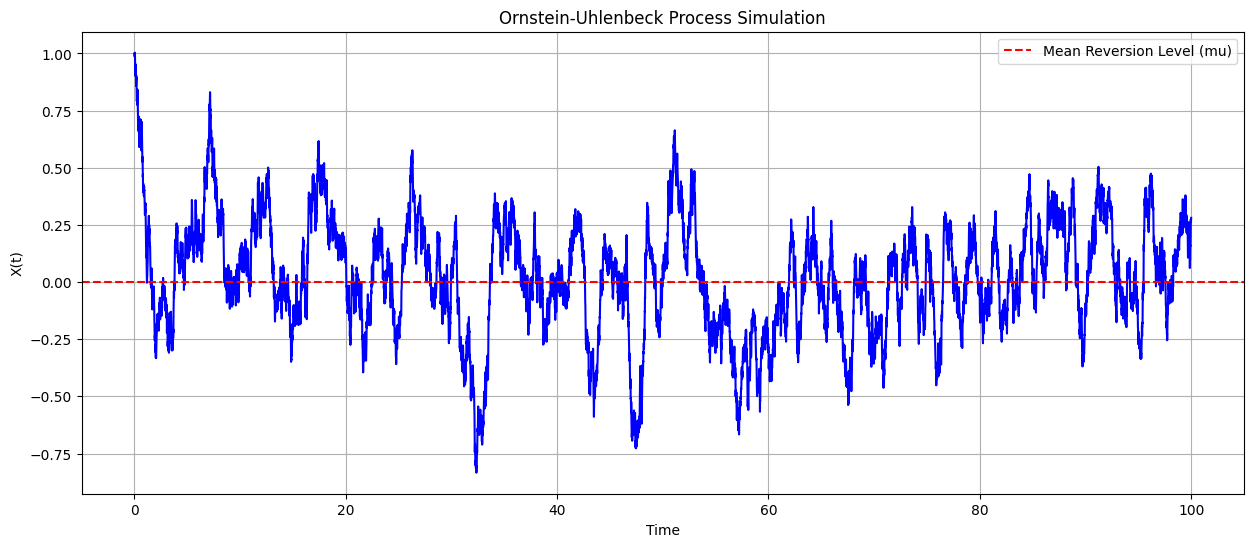

In [35]:
# pre-allocate array for efficiency
X = np.zeros(N)
X[0] = X0

# Generate the Ornstein-Uhlenbeck process
for t in range(1, N):
  dW = np.sqrt(dt) * np.random.normal() # Brownian increment
  X[t] = X[t-1] + theta * (mu - X[t-1]) * dt + sigma * dW
  
# Plot the results and include the mean reversion level
plt.figure(figsize=(15, 6))
plt.plot(np.linspace(0, T, N), X, color='blue')
plt.axhline(y=mu, color='red', linestyle='--', label='Mean Reversion Level (mu)')
plt.title('Ornstein-Uhlenbeck Process Simulation')
plt.xlabel('Time')
plt.ylabel('X(t)')
plt.legend()
plt.grid()
plt.show()

#### Time-Dependent Standard Deviation of the OU Process

For an Ornstein–Uhlenbeck process starting at $X_0$, the conditional distribution at time $t$ is:
$$
X_t \mid X_0 \sim \mathcal{N}\left(\mu + (X_0 - \mu)e^{-\theta t},\;
\frac{\sigma^2}{2\theta}\left(1 - e^{-2\theta t}\right)\right)
$$

> Conditional Mean
$
\mathbb{E}[X_t] = \mu + (X_0 - \mu)e^{-\theta t}
$

> Time-Dependent Variance
$
\mathrm{Var}(X_t) = \frac{\sigma^2}{2\theta}\left(1 - e^{-2\theta t}\right)
$

> Time-Dependent Standard Deviation
$
\sigma_t = \sqrt{\frac{\sigma^2}{2\theta}\left(1 - e^{-2\theta t}\right)}
$

### Confidence Bands

For a confidence level $k \in \{1,2,3\}$:

$$
\text{Upper}_t = \mathbb{E}[X_t] + k\sigma_t
$$
$$
\text{Lower}_t = \mathbb{E}[X_t] - k\sigma_t
$$

At $t = 0$, the variance is zero and the bands collapse to the initial value $X_0$.
As $t$ tend towards $\infty$, the bands converge to the stationary width $\pm k \frac{\sigma}{\sqrt{2\theta}}$.

In [36]:
def ornstein_uhlenbeck_simulation(theta, mu, sigma, X0, T, dt):
  N = int(T / dt)
  X = np.zeros(N)
  X[0] = X0
  # Generate the Ornstein-Uhlenbeck process
  for t in range(1, N):
    dW = np.sqrt(dt) * np.random.normal() # Brownian increment
    X[t] = X[t-1] + theta * (mu - X[t-1]) * dt + sigma * dW
  return X

def plot_ornstein_uhlenbeck_simulation(theta, mu, sigma, X0, T, dt, num_simulations):
  # Time grid
  t = np.linspace(0, T, int(T / dt))

  plt.figure(figsize=(15, 6))
  for _ in range(num_simulations):
    X = ornstein_uhlenbeck_simulation(theta, mu, sigma, X0, T, dt)
    plt.plot(t, X, alpha=0.5)
    
  # Time dependent bands
  # Time-dependent mean and standard deviation
  mean_t = mu + (X0 - mu) * np.exp(-theta * t)
  std_t = np.sqrt((sigma**2 / (2 * theta)) * (1 - np.exp(-2 * theta * t)))

  # Confidence bands (±2σ)
  upper_band = mean_t + 2 * std_t
  lower_band = mean_t - 2 * std_t
  plt.plot(t, mean_t, color='red', linestyle='--', label='Mean Reversion Level (mu)')
  plt.plot(t, upper_band, label='Upper Band (mu + 2σ)', color='green', linestyle='--')
  plt.plot(t, lower_band, label='Lower Band (mu - 2σ)', color='green', linestyle='--')
  plt.title('Ornstein-Uhlenbeck Process Simulations')
  plt.xlabel('Time')
  plt.ylabel('X(t)')
  plt.legend()
  plt.grid()
  plt.show()

**Simulate our visualisation**

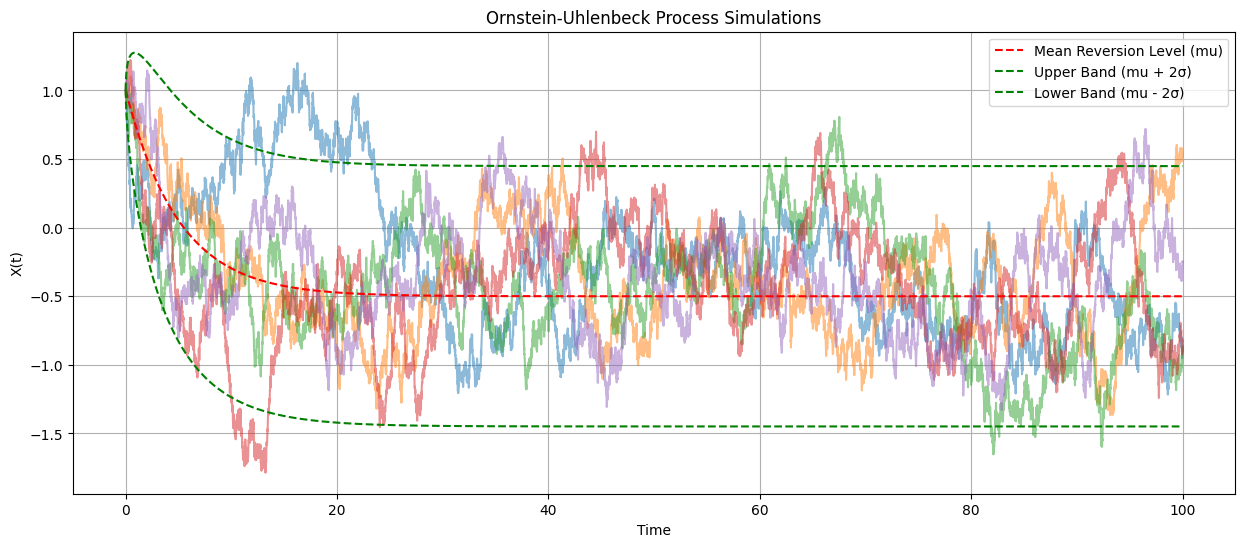

In [39]:
theta = 0.2 # Speed of reversion
mu = -0.5 # Long-term mean
sigma = 0.3 # Volatility
X0 = 1.0 # Initial value
T = 100.0 # Total time
dt = 0.01 # Time step
num_simulations = 5 # Number of simulations to plot

plot_ornstein_uhlenbeck_simulation(theta, mu, sigma, X0, T, dt, num_simulations)

As illustrated in the visualisation above, varying the model parameters reveals a consistent tendency for the simulated paths to revert toward the long-run mean once deviations exceed approximately two standard deviations. These upper and lower bands correspond to the stationary distribution of the Ornstein–Uhlenbeck process and serve as probabilistic boundaries rather than hard limits. When the process moves beyond these thresholds, the strength of the mean-reverting drift increases, counteracting the stochastic shocks and pulling the trajectory back toward equilibrium. This behaviour clearly demonstrates the defining characteristic of the OU process: a dynamic balance between random fluctuations and deterministic mean reversion, where extreme deviations are statistically less persistent over time.